In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Setting project paths

cwd = Path.cwd().resolve()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd

MODEL_DATA_PATH = BASE_DIR / "data" / "processed" / "modeling_dataset.csv"

RF_PRED_PATH = BASE_DIR / "data" / "processed" / "random_forest_three_option_test_policy_predictions.csv"
XGB_PRED_PATH = BASE_DIR / "data" / "processed" / "xgboost_three_option_test_policy_predictions.csv"

OUTPUT_DIR = BASE_DIR / "outputs" / "policy_comparison"
FIGURE_DIR = BASE_DIR / "outputs" / "final_figures" / "policy_comparison"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Model data:", MODEL_DATA_PATH)
print("RF predictions:", RF_PRED_PATH)
print("XGBoost predictions:", XGB_PRED_PATH)

Base directory: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis
Model data: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\modeling_dataset.csv
RF predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\random_forest_three_option_test_policy_predictions.csv
XGBoost predictions: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\xgboost_three_option_test_policy_predictions.csv


In [3]:
# Checking required files

required_files = [
    MODEL_DATA_PATH,
    RF_PRED_PATH,
    XGB_PRED_PATH
]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Required file not found: {file_path}")

print("All required files are available.")

All required files are available.


In [4]:
# Loading datasets

fleet_df = pd.read_csv(MODEL_DATA_PATH)
rf_pred_df = pd.read_csv(RF_PRED_PATH)
xgb_pred_df = pd.read_csv(XGB_PRED_PATH)

fleet_df["date"] = pd.to_datetime(fleet_df["date"])
rf_pred_df["date"] = pd.to_datetime(rf_pred_df["date"])
xgb_pred_df["date"] = pd.to_datetime(xgb_pred_df["date"])

fleet_df = fleet_df.sort_values(["blower_id", "date"]).copy()
rf_pred_df = rf_pred_df.sort_values(["blower_id", "date"]).copy()
xgb_pred_df = xgb_pred_df.sort_values(["blower_id", "date"]).copy()

print("Fleet dataset:", fleet_df.shape)
print("RF prediction dataset:", rf_pred_df.shape)
print("XGBoost prediction dataset:", xgb_pred_df.shape)

fleet_df.head()

Fleet dataset: (4380, 34)
RF prediction dataset: (1104, 15)
XGBoost prediction dataset: (1104, 15)


,date,amb_temp_max_c,amb_temp_min_c,amb_temp_avg_c,humidity,wind_gust_kph,blower_id,site_id,operational_class,max_op_ambient_temp_c,...,health_score,maintenance_event_triggered,failure_event,RUL_days,maintenance_due_90d,previous_maintenance_event,maintenance_cycle,days_since_maintenance,cycle_start_cumulative_hours,hours_since_maintenance
0,2025-01-01,35.777778,23.555556,29.333333,63.9,17.2,ZG150_B001,Site_01,High Duty,48.9,...,99.262303,0,0,165.103543,0,0,0,0,22.457076,0.000000
1,2025-01-02,31.777778,20.722222,26.055556,79.5,15.0,ZG150_B001,Site_01,High Duty,48.9,...,98.703011,0,0,164.173270,0,0,0,1,22.457076,20.440024
2,2025-01-03,31.611111,22.222222,26.611111,78.3,13.9,ZG150_B001,Site_01,High Duty,48.9,...,98.176655,0,0,163.297779,0,0,0,2,22.457076,43.565701
3,2025-01-04,32.722222,23.722222,28.000000,71.4,12.9,ZG150_B001,Site_01,High Duty,48.9,...,97.606606,0,0,162.349612,0,0,0,3,22.457076,66.976548
4,2025-01-05,34.111111,22.500000,29.388889,66.3,19.8,ZG150_B001,Site_01,High Duty,48.9,...,96.939732,0,0,161.240397,0,0,0,4,22.457076,86.976548


In [5]:
# Define policy assumptions

split_date = pd.Timestamp("2025-10-01")

# OEM fixed maintenance interval assumptions
oem_interval_scenarios = {
    "OEM 2000h":2000,
    "OEM 4000h":4000,
    "OEM 6000h":6000
}
oem_interval_days = 365

# Predictive maintenance trigger
rul_trigger_days = 90

# Prevent repeated maintenance on consecutive days after a warning
min_days_between_predictive_maintenance = 90

# Degradation thresholds
failure_threshold = 1.0
high_risk_threshold = 0.60

# Imperfect maintenance assumption
maintenance_recovery_factor = 0.2

# Cost assumptions
planned_maintenance_cost = 500
failure_repair_cost = 25000

# Downtime assumptions
planned_maintenance_downtime_hours = 4
failure_downtime_hours = 48

In [6]:
# Selecting Option A prediction columns

rf_rul_col = "Option_A_Full_Model_rf_predicted_RUL_days"
xgb_rul_col = "Option_A_Full_Model_predicted_RUL_days"

required_rf_cols = ["date", "blower_id", rf_rul_col]
required_xgb_cols = ["date", "blower_id", xgb_rul_col]

missing_rf_cols = [col for col in required_rf_cols if col not in rf_pred_df.columns]
missing_xgb_cols = [col for col in required_xgb_cols if col not in xgb_pred_df.columns]

if missing_rf_cols:
    raise ValueError(f"Missing RF prediction columns: {missing_rf_cols}")

if missing_xgb_cols:
    raise ValueError(f"Missing XGBoost prediction columns: {missing_xgb_cols}")

print("RF prediction column:", rf_rul_col)
print("XGBoost prediction column:", xgb_rul_col)

RF prediction column: Option_A_Full_Model_rf_predicted_RUL_days
XGBoost prediction column: Option_A_Full_Model_predicted_RUL_days


In [7]:
# Preparing test-period base dataset and merging ML predictions

test_base_df = fleet_df[fleet_df["date"] >= split_date].copy()

rf_keep = rf_pred_df[["date", "blower_id", rf_rul_col]].copy()
xgb_keep = xgb_pred_df[["date", "blower_id", xgb_rul_col]].copy()

policy_test_df = (
    test_base_df
    .merge(rf_keep, on=["date", "blower_id"], how="left")
    .merge(xgb_keep, on=["date", "blower_id"], how="left")
)

print("Policy test dataset:", policy_test_df.shape)
print("Missing RF predictions:", policy_test_df[rf_rul_col].isna().sum())
print("Missing XGBoost predictions:", policy_test_df[xgb_rul_col].isna().sum())

if policy_test_df[rf_rul_col].isna().sum() > 0:
    raise ValueError("Some RF predictions are missing after merge.")

if policy_test_df[xgb_rul_col].isna().sum() > 0:
    raise ValueError("Some XGBoost predictions are missing after merge.")

policy_test_df.head()

Policy test dataset: (1104, 36)
Missing RF predictions: 0
Missing XGBoost predictions: 0


,date,amb_temp_max_c,amb_temp_min_c,amb_temp_avg_c,humidity,wind_gust_kph,blower_id,site_id,operational_class,max_op_ambient_temp_c,...,failure_event,RUL_days,maintenance_due_90d,previous_maintenance_event,maintenance_cycle,days_since_maintenance,cycle_start_cumulative_hours,hours_since_maintenance,Option_A_Full_Model_rf_predicted_RUL_days,Option_A_Full_Model_predicted_RUL_days
0,2025-10-01,24.333333,12.833333,18.666667,67.9,17.9,ZG150_B001,Site_01,High Duty,48.9,...,0,135.921858,1,0,3,12,5736.380885,267.828758,147.817747,149.79317
1,2025-10-02,33.222222,10.055556,22.055556,53.5,32.7,ZG150_B001,Site_01,High Duty,48.9,...,0,134.992977,1,0,3,13,5736.380885,291.828758,151.954224,147.89233
2,2025-10-03,22.333333,16.055556,19.444444,69.2,27.7,ZG150_B001,Site_01,High Duty,48.9,...,0,134.287447,1,0,3,14,5736.380885,314.407528,152.438145,143.92660
3,2025-10-04,21.055556,13.333333,17.888889,74.3,21.7,ZG150_B001,Site_01,High Duty,48.9,...,0,133.479955,1,0,3,15,5736.380885,335.262942,147.262996,144.90166
4,2025-10-05,30.666667,14.222222,22.500000,59.4,18.1,ZG150_B001,Site_01,High Duty,48.9,...,0,132.430452,1,0,3,16,5736.380885,355.594325,150.449018,142.97249


In [8]:
initial_state_df = (
    fleet_df[fleet_df["date"] < split_date]
    .sort_values(["blower_id", "date"])
    .groupby("blower_id")
    .tail(1)
    .set_index("blower_id")
)

def simulate_policy_from_same_start(
    policy_test_df,
    policy_name,
    policy_type,
    prediction_col=None,
    oem_interval_hours_used=None
):
    results = []

    for blower_id, group in policy_test_df.groupby("blower_id"):
        group = group.sort_values("date").copy()

        current_degradation = initial_state_df.loc[blower_id, "degradation_index"]
        hours_since_maintenance = initial_state_df.loc[blower_id, "hours_since_maintenance"]
        days_since_maintenance = initial_state_df.loc[blower_id, "days_since_maintenance"]

        days_since_policy_maintenance = min_days_between_predictive_maintenance

        degradation_values = []
        maintenance_events = []
        failure_events = []
        high_risk_days = []
        health_scores = []

        for _, row in group.iterrows():
            maintenance_event = 0
            failure_event = 0

            if policy_type == "OEM":
                if oem_interval_hours_used is None:
                    raise ValueError("OEM policy requires oem_interval_hours_used.")

                due_for_maintenance = (
                    hours_since_maintenance >= oem_interval_hours_used
                    or days_since_maintenance >= oem_interval_days
                )

            elif policy_type == "PdM":
                if prediction_col is None:
                    raise ValueError("PdM policy requires prediction_col.")

                predicted_rul = row[prediction_col]

                due_for_maintenance = (
                    predicted_rul <= rul_trigger_days
                    and days_since_policy_maintenance >= min_days_between_predictive_maintenance
                )

            else:
                raise ValueError("policy_type must be either 'OEM' or 'PdM'.")

            if due_for_maintenance:
                maintenance_event = 1
                current_degradation = current_degradation * maintenance_recovery_factor
                hours_since_maintenance = 0
                days_since_maintenance = 0
                days_since_policy_maintenance = 0

            current_degradation += row["daily_degradation"]
            hours_since_maintenance += row["daily_op_hours"]
            days_since_maintenance += 1
            days_since_policy_maintenance += 1

            if current_degradation >= failure_threshold:
                failure_event = 1
                current_degradation = current_degradation * maintenance_recovery_factor
                hours_since_maintenance = 0
                days_since_maintenance = 0
                days_since_policy_maintenance = 0

            health_score = max(
                0,
                100 * (1 - current_degradation / failure_threshold)
            )

            high_risk_day = int(current_degradation >= high_risk_threshold)

            degradation_values.append(current_degradation)
            health_scores.append(health_score)
            maintenance_events.append(maintenance_event)
            failure_events.append(failure_event)
            high_risk_days.append(high_risk_day)

        group["policy"] = policy_name
        group["policy_type"] = policy_type
        group["oem_interval_hours"] = oem_interval_hours_used
        group["policy_degradation_index"] = degradation_values
        group["policy_health_score"] = health_scores
        group["policy_maintenance_event"] = maintenance_events
        group["policy_failure_event"] = failure_events
        group["policy_high_risk_day"] = high_risk_days

        results.append(group)

    return pd.concat(results, ignore_index=True)

In [9]:
# Running OEM interval sensitivity and predictive maintenance simulations

policy_results = []

# OEM sensitivity scenarios
for policy_name, interval_hours in oem_interval_scenarios.items():
    oem_policy_df = simulate_policy_from_same_start(
        policy_test_df=policy_test_df,
        policy_name=policy_name,
        policy_type="OEM",
        prediction_col=None,
        oem_interval_hours_used=interval_hours
    )

    policy_results.append(oem_policy_df)

# Random Forest predictive maintenance policy
rf_policy_df = simulate_policy_from_same_start(
    policy_test_df=policy_test_df,
    policy_name="Random Forest PdM",
    policy_type="PdM",
    prediction_col=rf_rul_col,
    oem_interval_hours_used=None
)

policy_results.append(rf_policy_df)

# XGBoost predictive maintenance policy
xgb_policy_df = simulate_policy_from_same_start(
    policy_test_df=policy_test_df,
    policy_name="XGBoost PdM",
    policy_type="PdM",
    prediction_col=xgb_rul_col,
    oem_interval_hours_used=None
)

policy_results.append(xgb_policy_df)

policy_df = pd.concat(
    policy_results,
    ignore_index=True
)

print("Combined policy comparison dataset:", policy_df.shape)

policy_df[[
    "date",
    "blower_id",
    "policy",
    "policy_type",
    "oem_interval_hours",
    "policy_degradation_index",
    "policy_maintenance_event"
]].head()

Combined policy comparison dataset: (5520, 44)


,date,blower_id,policy,policy_type,oem_interval_hours,policy_degradation_index,policy_maintenance_event
0,2025-10-01,ZG150_B001,OEM 2000h,OEM,2000,0.182821,0
1,2025-10-02,ZG150_B001,OEM 2000h,OEM,2000,0.188405,0
2,2025-10-03,ZG150_B001,OEM 2000h,OEM,2000,0.192647,0
3,2025-10-04,ZG150_B001,OEM 2000h,OEM,2000,0.197502,0
4,2025-10-05,ZG150_B001,OEM 2000h,OEM,2000,0.203812,0


In [10]:
# Creating main policy comparison summary

policy_summary = (
    policy_df
    .groupby("policy")
    .agg(
        maintenance_events=("policy_maintenance_event", "sum"),
        failure_events=("policy_failure_event", "sum"),
        high_risk_days=("policy_high_risk_day", "sum"),
        avg_degradation=("policy_degradation_index", "mean"),
        max_degradation=("policy_degradation_index", "max"),
        avg_health_score=("policy_health_score", "mean")
    )
    .reset_index()
)

policy_summary["maintenance_cost"] = (
    policy_summary["maintenance_events"] * planned_maintenance_cost
)

policy_summary["failure_cost"] = (
    policy_summary["failure_events"] * failure_repair_cost
)

policy_summary["total_cost"] = (
    policy_summary["maintenance_cost"] + policy_summary["failure_cost"]
)

policy_summary["planned_maintenance_downtime_hours"] = (
    policy_summary["maintenance_events"] * planned_maintenance_downtime_hours
)

policy_summary["failure_downtime_hours"] = (
    policy_summary["failure_events"] * failure_downtime_hours
)

policy_summary["total_downtime_hours"] = (
    policy_summary["planned_maintenance_downtime_hours"]
    + policy_summary["failure_downtime_hours"]
)

policy_order = [
    "OEM 2000h",
    "OEM 4000h",
    "OEM 6000h",
    "Random Forest PdM",
    "XGBoost PdM"
]

policy_summary["policy"] = pd.Categorical(
    policy_summary["policy"],
    categories=policy_order,
    ordered=True
)

policy_summary = (
    policy_summary
    .sort_values("policy")
    .reset_index(drop=True)
)

In [11]:
#Creating blower policy comparison

blower_policy_summary = (
    policy_df
    .groupby(["policy", "blower_id"])
    .agg(
        maintenance_events=("policy_maintenance_event", "sum"),
        failure_events=("policy_failure_event", "sum"),
        high_risk_days=("policy_high_risk_day", "sum"),
        avg_degradation=("policy_degradation_index", "mean"),
        max_degradation=("policy_degradation_index", "max"),
        avg_health_score=("policy_health_score", "mean")
    )
    .reset_index()
)

blower_policy_summary.head()

,policy,blower_id,maintenance_events,failure_events,high_risk_days,avg_degradation,max_degradation,avg_health_score
0,OEM 2000h,ZG150_B001,1,0,16,0.395097,0.681334,60.490340
1,OEM 2000h,ZG150_B002,1,0,9,0.382052,0.659003,61.794810
2,OEM 2000h,ZG150_B003,1,0,52,0.582343,0.919477,41.765662
3,OEM 2000h,ZG150_B004,1,0,36,0.507816,0.772851,49.218405
4,OEM 2000h,ZG200_B011,1,0,1,0.347844,0.600769,65.215619


In [12]:
# bar plots function
def plot_policy_bar(data, y_col, title, ylabel, filename, value_format="{:.0f}"):

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        data["policy"],
        data[y_col]
    )

    ax.bar_label(
        bars,
        labels=[value_format.format(v) for v in data[y_col]],
        label_type="edge"
    )

    ax.set_title(title)
    ax.set_xlabel("Maintenance Policy")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y")

    plt.tight_layout()

    fig.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

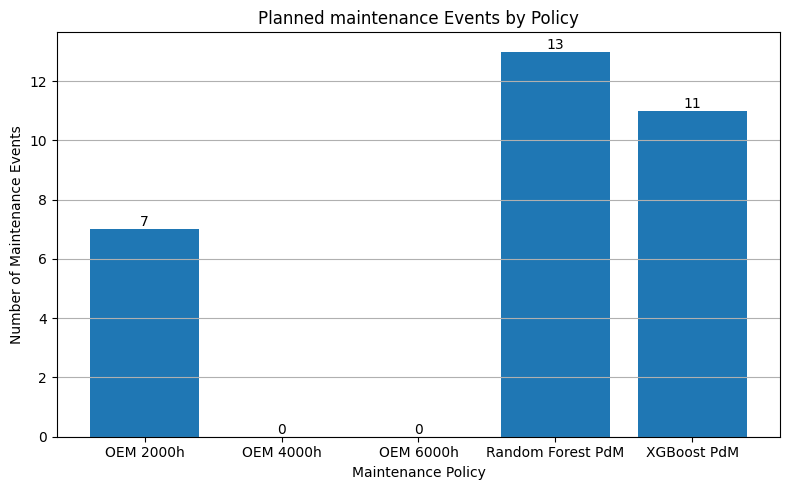

In [13]:
# Maintenance events plot

plot_policy_bar(
    data=policy_summary,
    y_col="maintenance_events",
    title="Planned maintenance Events by Policy",
    ylabel="Number of Maintenance Events",
    filename="maintenance_events_by_policy.png",
    value_format="{:.0f}"
)

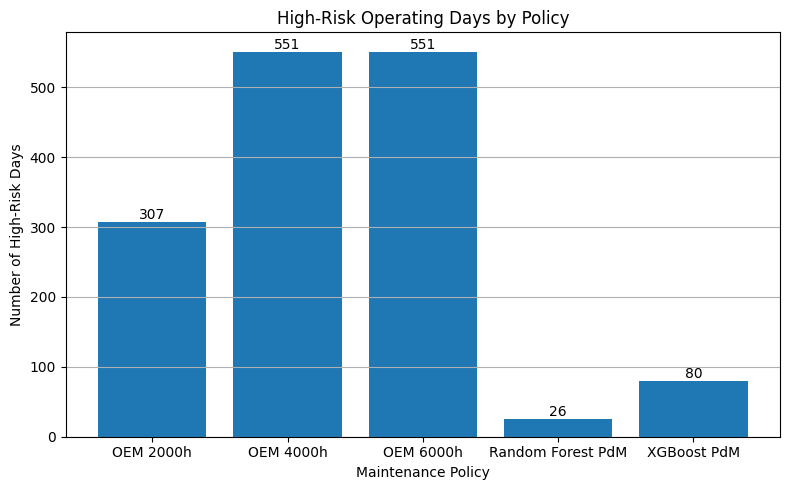

In [14]:
# High-risk days plot

plot_policy_bar(
    data=policy_summary,
    y_col="high_risk_days",
    title="High-Risk Operating Days by Policy",
    ylabel="Number of High-Risk Days",
    filename="high_risk_days_by_policy.png",
    value_format="{:.0f}"
)

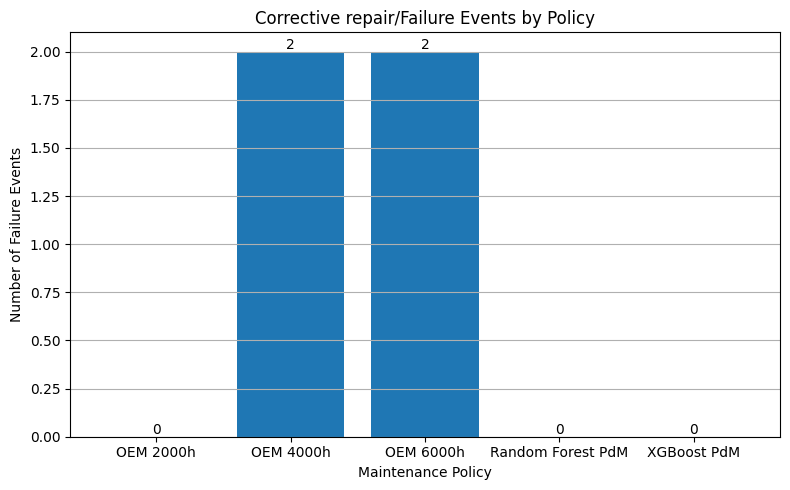

In [15]:
# failure events plot

plot_policy_bar(
    data=policy_summary,
    y_col="failure_events",
    title="Corrective repair/Failure Events by Policy",
    ylabel="Number of Failure Events",
    filename="failure_events_by_policy.png",
    value_format="{:.0f}"
)

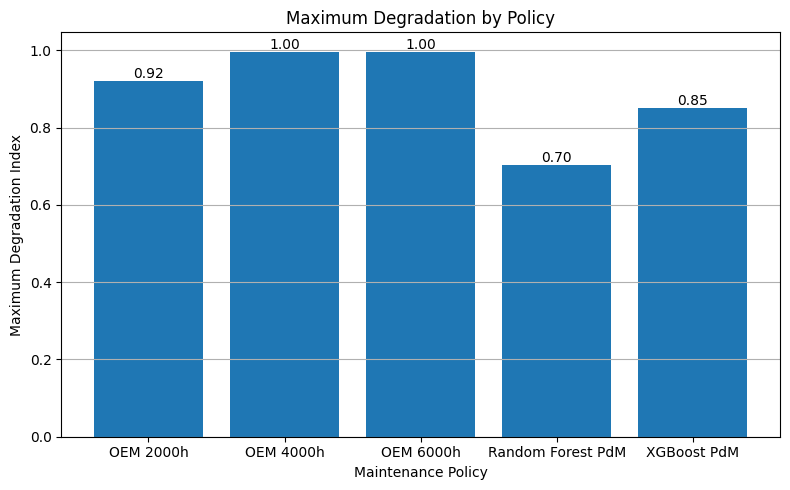

In [16]:
# maximum degradation plot

plot_policy_bar(
    data=policy_summary,
    y_col="max_degradation",
    title="Maximum Degradation by Policy",
    ylabel="Maximum Degradation Index",
    filename="maximum_degradation_by_policy.png",
    value_format="{:.2f}"
)

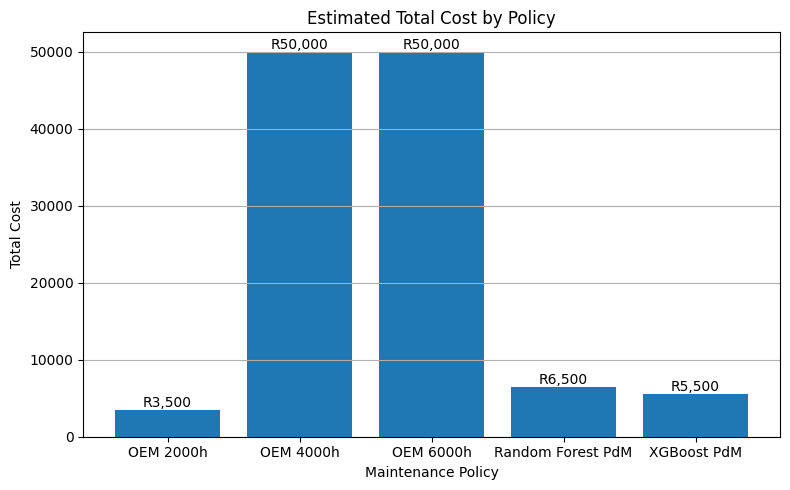

In [17]:
# Cost plot

plot_policy_bar(
    data=policy_summary,
    y_col="total_cost",
    title="Estimated Total Cost by Policy",
    ylabel="Total Cost",
    filename="total_cost_by_policy.png",
    value_format="R{:,.0f}"
)

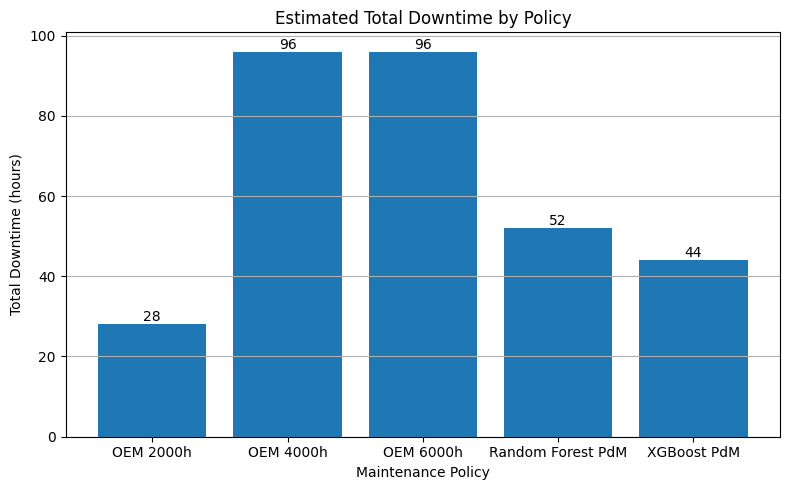

In [18]:
# downtime total plot

plot_policy_bar(
    data=policy_summary,
    y_col="total_downtime_hours",
    title="Estimated Total Downtime by Policy",
    ylabel="Total Downtime (hours)",
    filename="total_downtime_by_policy.png",
    value_format="{:.0f}"
)

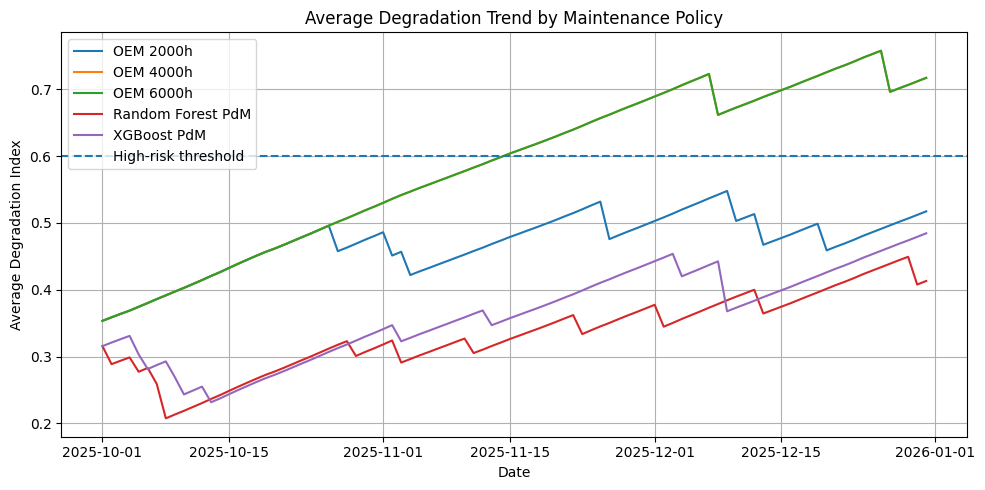

In [19]:
# Plotting average degradation trend by policy

avg_degradation_trend = (
    policy_df
    .groupby(["date", "policy"])["policy_degradation_index"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

for policy in avg_degradation_trend["policy"].unique():
    subset = avg_degradation_trend[
        avg_degradation_trend["policy"] == policy
    ]

    ax.plot(
        subset["date"],
        subset["policy_degradation_index"],
        label=policy
    )

ax.axhline(
    y=high_risk_threshold,
    linestyle="--",
    label="High-risk threshold"
)

ax.set_title("Average Degradation Trend by Maintenance Policy")
ax.set_xlabel("Date")
ax.set_ylabel("Average Degradation Index")
ax.legend()
ax.grid(True)

plt.tight_layout()

fig.savefig(
    FIGURE_DIR / "average_degradation_trend_by_policy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Saving policy comparison outputs

policy_df_path = PROCESSED_DIR / "maintenance_policy_comparison_dataset.csv"
policy_summary_path = OUTPUT_DIR / "maintenance_policy_summary.csv"
blower_policy_summary_path = OUTPUT_DIR / "blower_level_maintenance_policy_summary.csv"

policy_df.to_csv(policy_df_path, index=False)
policy_summary.to_csv(policy_summary_path, index=False)
blower_policy_summary.to_csv(blower_policy_summary_path, index=False)

print("Saved policy comparison dataset to:", policy_df_path)
print("Saved policy summary to:", policy_summary_path)
print("Saved blower-level policy summary to:", blower_policy_summary_path)

Saved policy comparison dataset to: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\maintenance_policy_comparison_dataset.csv
Saved policy summary to: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\policy_comparison\maintenance_policy_summary.csv
Saved blower-level policy summary to: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\policy_comparison\blower_level_maintenance_policy_summary.csv


In [21]:
# Final summary

print("Maintenance policy comparison completed.")

print("\nPolicy Summary:")
display(policy_summary)

print("\nSaved outputs:")
print(f"- Full policy comparison dataset: {policy_df_path}")
print(f"- Policy summary: {policy_summary_path}")
print(f"- Blower-level policy summary: {blower_policy_summary_path}")
print(f"- Figures: {FIGURE_DIR}")

Maintenance policy comparison completed.

Policy Summary:


,policy,maintenance_events,failure_events,high_risk_days,avg_degradation,max_degradation,avg_health_score,maintenance_cost,failure_cost,total_cost,planned_maintenance_downtime_hours,failure_downtime_hours,total_downtime_hours
0,OEM 2000h,7,0,307,0.469030,0.919477,53.096961,3500,0,3500,28,0,28
1,OEM 4000h,0,2,551,0.583966,0.996420,41.603372,0,50000,50000,0,96,96
2,OEM 6000h,0,2,551,0.583966,0.996420,41.603372,0,50000,50000,0,96,96
3,Random Forest PdM,13,0,26,0.333353,0.702095,66.664736,6500,0,6500,52,0,52
4,XGBoost PdM,11,0,80,0.362585,0.849661,63.741533,5500,0,5500,44,0,44



Saved outputs:
- Full policy comparison dataset: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\data\processed\maintenance_policy_comparison_dataset.csv
- Policy summary: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\policy_comparison\maintenance_policy_summary.csv
- Blower-level policy summary: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\policy_comparison\blower_level_maintenance_policy_summary.csv
- Figures: C:\Users\USER\Documents\Shool projects\Predictive_Maintenance_Thesis\outputs\final_figures\policy_comparison
